In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ds = xr.open_dataset("../../../NC/compare.nc")  

In [ ]:
def get_diff_quar(ds, name, time):
    global diff_v
    # 构造变量名
    var_basin  = f"basin_{name}"
    var_region = f"region_{name}"

    # 取该年数据
    da_basin  = ds[var_basin].sel(time=time)
    da_region = ds[var_region].sel(time=time)

    # 差值
    diff = da_region - da_basin

    # 有效区域 mask（至少一个 > 0）
    mask = (da_basin > 0) | (da_region > 0)

    # 应用 mask → 无效格点变为 NaN
    diff_v = diff.where(mask)
    vals = diff_v.values.flatten()
    vals = vals[~np.isnan(vals)]

    Q1     = np.percentile(vals, 25)
    Median = np.percentile(vals, 50)
    Q3     = np.percentile(vals, 75)
    IQR    = Q3 - Q1

    return Q1,Median,Q3,IQR

In [ ]:
years = list(range(2010, 2101, 10))   # 2010,2020,...,2100
years.insert(0, 2005)
year = "2100"
names = ["agri","forest","grassland"]
time =f"{year}-01-01"

for name in names:
    Q1_list, Median_list, Q3_list, IQR_list = [], [], [], []
    for i in years:
        time =f"{i}-01-01"
        Q1,Median,Q3,IQR=get_diff_quar(ds, name, time)
        Q1_list.append(Q1)
        Median_list.append(Median)
        Q3_list.append(Q3)
        IQR_list.append(IQR)

    plt.figure(figsize=(8,5))

    # ① Q1–Q3 带状区间（ribbon）
    plt.fill_between(
        years,
        Q1_list,
        Q3_list,
        alpha=0.3,
        label="Q1–Q3 range"
    )

    # ② 中位数折线
    plt.plot(
        years,
        Median_list,
        linewidth=2,
        label="Median"
    )

    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Difference (region − basin)", fontsize=14)
    plt.grid(True)
    plt.legend(loc="upper left")

    plt.savefig(
        f"../../../plot/analysis/{name}_ribbon_without_title.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

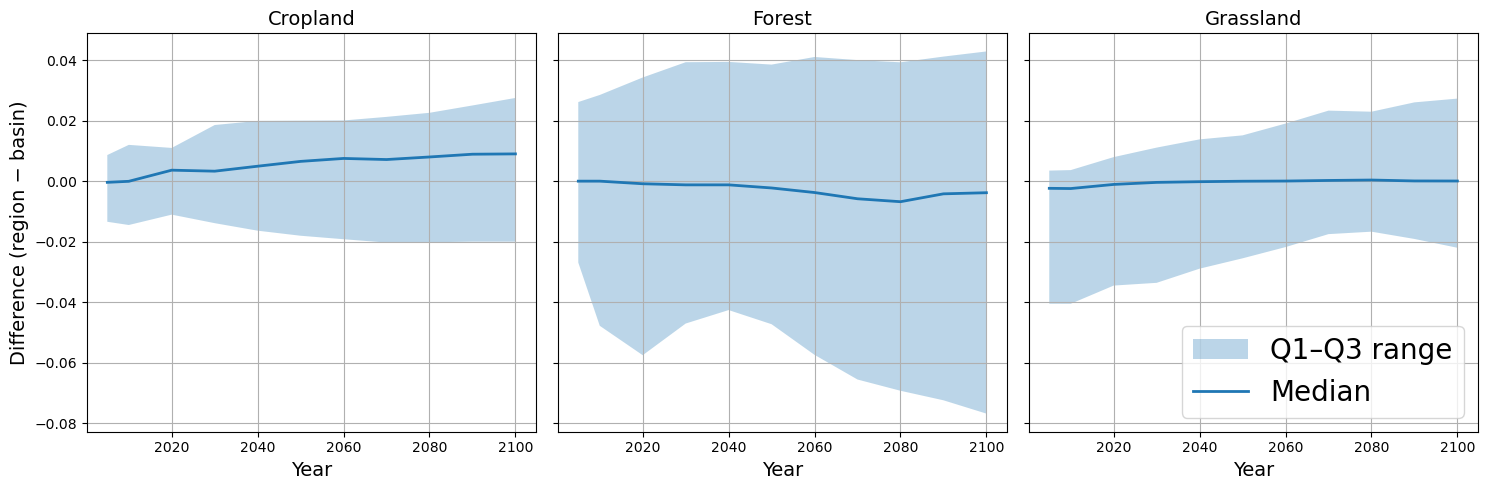

In [9]:
titles = ["Cropland", "Forest", "Grassland"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharey=True
)

for ax, name, title,in zip(axes, names, titles):

    Q1_list, Median_list, Q3_list = [], [], []

    for y in years:
        time = f"{y}-01-01"
        Q1, Median, Q3, IQR = get_diff_quar(ds, name, time)
        Q1_list.append(Q1)
        Median_list.append(Median)
        Q3_list.append(Q3)

    # ① Q1–Q3 ribbon
    ax.fill_between(
        years,
        Q1_list,
        Q3_list,
        alpha=0.3,
        label="Q1–Q3 range"
    )

    # ② Median line
    ax.plot(
        years,
        Median_list,
        linewidth=2,
        label="Median"
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Year", fontsize=14)
    ax.grid(True)

# 统一 y 轴标签（只放在最左）
axes[0].set_ylabel("Difference (region − basin)", fontsize=14)

# 只放一个 legend（右上角）
axes[-1].legend(loc="lower right",fontsize=20)

plt.tight_layout()

plt.savefig(
    "../../../plot/analysis/ribbon_all_landuse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()